<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/20260511_GWTC_localisation_volume_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install -q gwosc astropy pandas numpy matplotlib requests

Catalogues to try:
 - GWTC-1-confident
 - GWTC-2-confident
 - GWTC-2.1-confident
 - GWTC-3-confident
 - GWTC-4-confident

Fetching catalogue: GWTC-1-confident
  Events found: 11
Could not fetch detail for GW170817: 502 Server Error: Proxy Error for url: https://gwosc.org/eventapi/json/GWTC-1-confident/GW170817/v3

Fetching catalogue: GWTC-2-confident
  Skipping GWTC-2-confident: 404 Client Error: Not Found for url: https://gwosc.org/eventapi/json/GWTC-2-confident/

Fetching catalogue: GWTC-2.1-confident
  Events found: 54
Could not fetch detail for GW190828_063405: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

Fetching catalogue: GWTC-3-confident
  Events found: 35
Could not fetch detail for GW200219_094415: 502 Server Error: Proxy Error for url: https://gwosc.org/eventapi/json/GWTC-3-confident/GW200219_094415/v1

Fetching catalogue: GWTC-4-confident
  Skipping GWTC-4-confident: 404 Client Error: Not Found for url: https://gwosc.org/event

,commonName,catalog,event_date,sky_area_deg2,d_low_mpc,d_high_mpc,approx_volume_mpc3
62,GW150914,GWTC-2.1-confident,2015-09-14 09:51:21.400,250.0,310.0,610.0,5.005626e+06
61,GW151012,GWTC-2.1-confident,2015-10-12 09:55:19.400,1700.0,510.0,1640.0,7.385041e+08
60,GW151226,GWTC-2.1-confident,2015-12-26 03:39:29.600,950.0,260.0,620.0,2.129422e+07
59,GW170104,GWTC-2.1-confident,2017-01-04 10:12:35.600,1000.0,630.0,1500.0,3.173050e+08
58,GW170608,GWTC-2.1-confident,2017-06-08 02:01:53.500,380.0,210.0,460.0,3.398363e+06


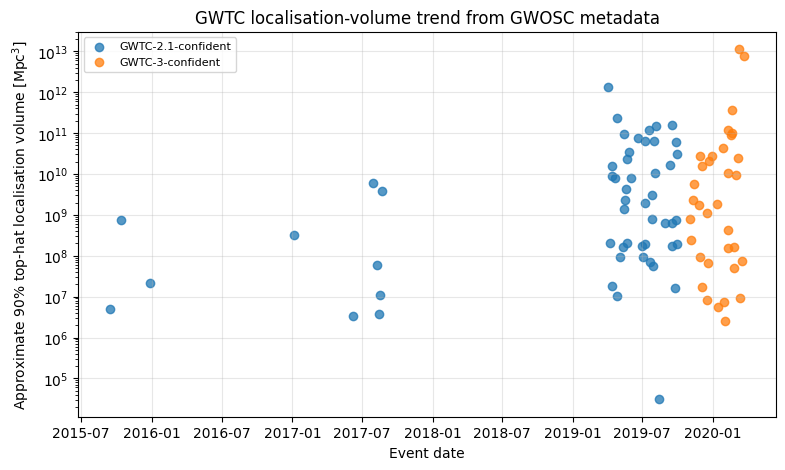

,catalog,n_events,median_volume_mpc3,p16_volume_mpc3,p84_volume_mpc3,catalog_rank
0,GWTC-2.1-confident,53,7.836105e+08,3.211109e+07,6.176014e+10,2
1,GWTC-3-confident,34,1.813329e+09,2.611310e+07,7.742318e+10,3


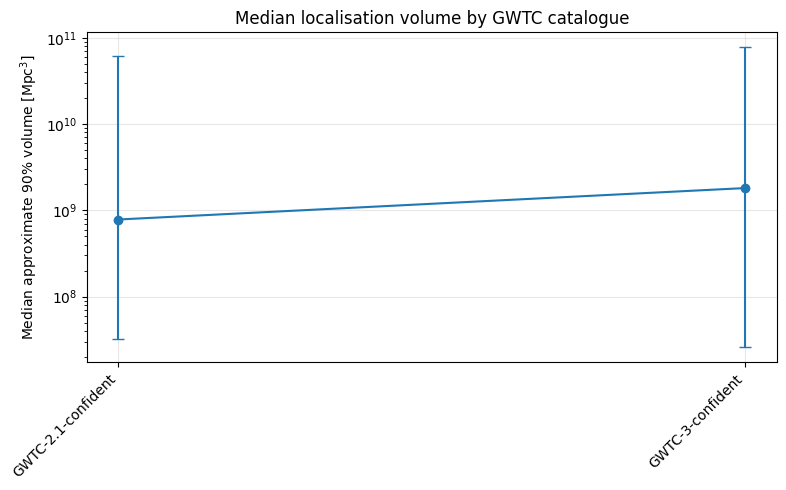


GW190814 quick comparison
------------------------
Approx. volume: 30,941 Mpc^3
Percentile among retained events: 1.1%


In [3]:
# ============================================================
# GWTC localisation-volume trend plot
#
# Purpose:
#   Pull GWOSC event metadata and estimate approximate 90% localisation volumes:
#
#       V ≈ (Omega / 3) * (d_high^3 - d_low^3)
#
#   where:
#       Omega = 90% sky area in steradians
#       d_low / d_high = luminosity-distance interval from GWOSC metadata
#
# Notes:
#   - This is a quick-look / meeting-plot calculation.
#   - It does NOT compute full 3D posterior volumes from skymaps.
#   - It uses the catalogue-reported sky area and distance interval.
# ============================================================

# If needed in a fresh notebook, uncomment:
# !pip install -q gwosc astropy pandas numpy matplotlib requests

import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gwosc.api import fetch_cataloglist_json, fetch_catalog_json
from astropy.time import Time


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def flatten_events(catalog_json):
    """
    Return a list of event records from whatever structure GWOSC returns.
    """
    events = catalog_json.get("events", catalog_json)

    if isinstance(events, dict):
        return list(events.values())

    if isinstance(events, list):
        return events

    return []


def collect_catalog_names(obj):
    """
    Recursively collect possible catalogue names from GWOSC catalogue-list JSON.
    """
    names = set()

    if isinstance(obj, dict):
        for key, value in obj.items():
            if isinstance(key, str) and "GWTC" in key and "confident" in key:
                names.add(key)

            if key in ["shortName", "name", "catalog.shortName"] and isinstance(value, str):
                if "GWTC" in value and "confident" in value:
                    names.add(value)

            names |= collect_catalog_names(value)

    elif isinstance(obj, list):
        for item in obj:
            names |= collect_catalog_names(item)

    return names


def choose_preferred_parameter_set(event_record):
    """
    Pick the preferred PE parameter set where possible.
    Falls back to any PE parameter set with sky_area.
    Falls back to the event record itself.
    """
    params = event_record.get("parameters", {})

    if isinstance(params, dict) and len(params) > 0:
        param_list = list(params.values())

        preferred = [
            p for p in param_list
            if isinstance(p, dict) and p.get("is_preferred") is True
        ]
        if preferred:
            return preferred[0]

        pe_with_sky = [
            p for p in param_list
            if isinstance(p, dict)
            and p.get("pipeline_type") == "pe"
            and p.get("sky_area") is not None
        ]
        if pe_with_sky:
            return pe_with_sky[0]

        pe_any = [
            p for p in param_list
            if isinstance(p, dict) and p.get("pipeline_type") == "pe"
        ]
        if pe_any:
            return pe_any[0]

    return event_record


def get_detail_event_record(event_summary):
    """
    Fetch detailed event JSON if jsonurl exists.
    If not, return the summary.
    """
    jsonurl = event_summary.get("jsonurl")

    if not jsonurl:
        return event_summary

    try:
        r = requests.get(jsonurl, timeout=60)
        r.raise_for_status()
        detail = r.json()

        detail_events = detail.get("events", {})
        if isinstance(detail_events, dict) and len(detail_events) > 0:
            return list(detail_events.values())[0]

        if isinstance(detail_events, list) and len(detail_events) > 0:
            return detail_events[0]

    except Exception as e:
        print(f"Could not fetch detail for {event_summary.get('commonName')}: {e}")

    return event_summary


def get_number(record, key):
    """
    Safely convert a GWOSC field to float.
    """
    value = record.get(key)
    if value is None:
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan


def distance_bounds_from_record(record):
    """
    GWOSC convention usually stores:
      luminosity_distance = median
      luminosity_distance_lower = negative offset
      luminosity_distance_upper = positive offset

    This function handles that, and also tries to be robust if signs are odd.
    """
    d = get_number(record, "luminosity_distance")
    lo = get_number(record, "luminosity_distance_lower")
    hi = get_number(record, "luminosity_distance_upper")

    if not np.isfinite(d) or not np.isfinite(lo) or not np.isfinite(hi):
        return np.nan, np.nan, np.nan

    # Usual GWOSC signed-offset convention
    if lo < 0:
        d_low = d + lo
    else:
        d_low = d - lo

    if hi > 0:
        d_high = d + hi
    else:
        d_high = d - hi

    if d_low <= 0 or d_high <= 0 or d_high <= d_low:
        return d, np.nan, np.nan

    return d, d_low, d_high


def sky_area_deg2_from_record(record):
    """
    Extract catalogue-reported sky area in deg^2.
    """
    for key in ["sky_area", "area_90", "Area90", "area90"]:
        value = get_number(record, key)
        if np.isfinite(value):
            return value

    return np.nan


def deg2_to_sr(area_deg2):
    return area_deg2 * (np.pi / 180.0) ** 2


def top_hat_volume(area_deg2, d_low, d_high):
    """
    Approximate top-hat volume in Mpc^3.
    """
    omega = deg2_to_sr(area_deg2)
    return (omega / 3.0) * (d_high**3 - d_low**3)


# ------------------------------------------------------------
# 1. Choose catalogues
# ------------------------------------------------------------

# Try to discover catalogue names dynamically
try:
    catalog_list_json = fetch_cataloglist_json()
    discovered_catalogs = collect_catalog_names(catalog_list_json)
except Exception as e:
    print("Could not fetch catalogue list dynamically:", e)
    discovered_catalogs = set()

# Fallback / safety list.
# Failed catalogues will simply be skipped.
fallback_catalogs = {
    "GWTC-1-confident",
    "GWTC-2-confident",
    "GWTC-2.1-confident",
    "GWTC-3-confident",
    "GWTC-4-confident",
}

catalogs = sorted(discovered_catalogs | fallback_catalogs)

# Keep confident GWTC catalogues only
catalogs = [
    c for c in catalogs
    if "GWTC" in c and "confident" in c and "marginal" not in c.lower()
]

print("Catalogues to try:")
for c in catalogs:
    print(" -", c)


# ------------------------------------------------------------
# 2. Pull events and estimate volumes
# ------------------------------------------------------------

rows = []

for catalog in catalogs:
    print(f"\nFetching catalogue: {catalog}")

    try:
        cat_json = fetch_catalog_json(catalog)
        events = flatten_events(cat_json)
        print(f"  Events found: {len(events)}")

    except Exception as e:
        print(f"  Skipping {catalog}: {e}")
        continue

    for k, event_summary in enumerate(events):
        common_name = event_summary.get("commonName")
        if common_name is None:
            continue

        # Fetch detailed record because sky_area often lives in preferred parameter set
        detail_record = get_detail_event_record(event_summary)
        param_record = choose_preferred_parameter_set(detail_record)

        gps = get_number(event_summary, "GPS")
        if not np.isfinite(gps):
            gps = get_number(detail_record, "GPS")

        area_deg2 = sky_area_deg2_from_record(param_record)
        d_med, d_low, d_high = distance_bounds_from_record(param_record)

        if not np.isfinite(area_deg2) or not np.isfinite(d_low) or not np.isfinite(d_high):
            continue

        volume_mpc3 = top_hat_volume(area_deg2, d_low, d_high)

        try:
            event_date = Time(gps, format="gps").datetime
        except Exception:
            event_date = pd.NaT

        rows.append({
            "commonName": common_name,
            "catalog": catalog,
            "GPS": gps,
            "event_date": event_date,
            "sky_area_deg2": area_deg2,
            "d_median_mpc": d_med,
            "d_low_mpc": d_low,
            "d_high_mpc": d_high,
            "approx_volume_mpc3": volume_mpc3,
            "approx_volume_gpc3": volume_mpc3 / 1e9,
        })

    # Gentle pause to avoid hammering GWOSC
    time.sleep(0.25)


all_events = pd.DataFrame(rows)

if len(all_events) == 0:
    raise RuntimeError(
        "No events with both sky_area and luminosity-distance bounds were found. "
        "Check GWOSC catalogue names or API availability."
    )

print(f"\nRows with usable volume estimates: {len(all_events)}")


# ------------------------------------------------------------
# 3. De-duplicate events
# ------------------------------------------------------------
# Some events appear in multiple catalogue releases.
# For a simple current-status trend, keep the latest available catalogue entry per commonName.

catalog_rank_order = {cat: i for i, cat in enumerate(catalogs)}

all_events["catalog_rank"] = all_events["catalog"].map(catalog_rank_order).fillna(-1)

events_unique = (
    all_events
    .sort_values(["commonName", "catalog_rank"])
    .drop_duplicates(subset=["commonName"], keep="last")
    .copy()
)

events_unique = events_unique.sort_values("event_date")

print(f"Unique events retained: {len(events_unique)}")

display(
    events_unique[
        [
            "commonName",
            "catalog",
            "event_date",
            "sky_area_deg2",
            "d_low_mpc",
            "d_high_mpc",
            "approx_volume_mpc3",
        ]
    ].head()
)


# ------------------------------------------------------------
# 4. Plot: approximate localisation volume vs event date
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for catalog, group in events_unique.groupby("catalog"):
    plt.scatter(
        group["event_date"],
        group["approx_volume_mpc3"],
        alpha=0.75,
        label=catalog
    )

plt.yscale("log")
plt.xlabel("Event date")
plt.ylabel("Approximate 90% top-hat localisation volume [Mpc$^3$]")
plt.title("GWTC localisation-volume trend from GWOSC metadata")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()


# ------------------------------------------------------------
# 5. Plot: median volume by catalogue/release
# ------------------------------------------------------------

release_summary = (
    events_unique
    .groupby("catalog")
    .agg(
        n_events=("commonName", "count"),
        median_volume_mpc3=("approx_volume_mpc3", "median"),
        p16_volume_mpc3=("approx_volume_mpc3", lambda x: x.quantile(0.16)),
        p84_volume_mpc3=("approx_volume_mpc3", lambda x: x.quantile(0.84)),
    )
    .reset_index()
)

release_summary["catalog_rank"] = release_summary["catalog"].map(catalog_rank_order).fillna(-1)
release_summary = release_summary.sort_values("catalog_rank")

display(release_summary)

plt.figure(figsize=(8, 5))

x = np.arange(len(release_summary))

y = release_summary["median_volume_mpc3"].values
yerr_lower = y - release_summary["p16_volume_mpc3"].values
yerr_upper = release_summary["p84_volume_mpc3"].values - y

plt.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=4
)

plt.yscale("log")
plt.xticks(x, release_summary["catalog"], rotation=45, ha="right")
plt.ylabel("Median approximate 90% volume [Mpc$^3$]")
plt.title("Median localisation volume by GWTC catalogue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Optional: compare GW190814 against the catalogue
# ------------------------------------------------------------

gw190814 = events_unique[events_unique["commonName"] == "GW190814"]

if len(gw190814) > 0:
    v = gw190814["approx_volume_mpc3"].iloc[0]
    percentile = (events_unique["approx_volume_mpc3"] <= v).mean() * 100

    print("\nGW190814 quick comparison")
    print("------------------------")
    print(f"Approx. volume: {v:,.0f} Mpc^3")
    print(f"Percentile among retained events: {percentile:.1f}%")
else:
    print("\nGW190814 not found in retained event table.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 1.7 MB/s eta 0:00:00

Fetching GWTC-1-confident
  Events listed: 11

Fetching GWTC-2
  Events listed: 39

Fetching GWTC-3-confident
  Events listed: 35

Fetching GWTC-4.0
  Events listed: 129

Initial extracted rows:
release_label
GWTC-1      11
GWTC-2      39
GWTC-3      35
GWTC-4.0    86
dtype: int64
Using Zenodo record 17014085
Skymap archive: IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps.tar.gz
This may take a few minutes.
Downloaded: IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps.tar.gz
Opening skymap archive...
Processed 10/86 O4 skymaps...
Processed 20/86 O4 skymaps...
Processed 30/86 O4 skymaps...
Processed 40/86 O4 skymaps...
Processed 50/86 O4 skymaps...
Processed 60/86 O4 skymaps...
Processed 70/86 O4 skymaps...
Processed 80/86 O4 skymaps...

Usable volume rows by release:
release_label
GWTC-1      11
GWTC-3      35
GWTC-4.0    86
dtype: int64

Rows missing sky_area by release:
release_label
GWTC-2    39
dtype: int64


,event_name,release_label,run,event_date,sky_area_deg2,d_low_mpc,d_high_mpc,approx_volume_mpc3
10,GW150914,GWTC-1,O1,2015-09-14 09:51:21.400,182.0,270.0,590.0,3.431685e+06
9,GW151012,GWTC-1,O1,2015-10-12 09:55:19.400,1523.0,590.0,1630.0,6.379639e+08
8,GW151226,GWTC-1,O1,2015-12-26 03:39:29.600,1033.0,260.0,630.0,2.438387e+07
7,GW170104,GWTC-1,O2,2017-01-04 10:12:35.600,921.0,560.0,1430.0,2.570415e+08
6,GW170608,GWTC-1,O2,2017-06-08 02:01:53.500,392.0,210.0,440.0,3.021989e+06
5,GW170729,GWTC-1,O2,2017-07-29 18:57:06.300,1041.0,1480.0,4240.0,7.714491e+09
4,GW170809,GWTC-1,O2,2017-08-09 08:28:58.800,308.0,640.0,1350.0,6.874760e+07
3,GW170814,GWTC-1,O2,2017-08-14 10:31:20.500,87.0,380.0,750.0,3.242070e+06
2,GW170817,GWTC-1,O2,2017-08-17 12:41:41.400,16.0,25.0,47.0,1.432888e+02
1,GW170818,GWTC-1,O2,2017-08-18 02:25:46.100,39.0,680.0,1480.0,1.159242e+07


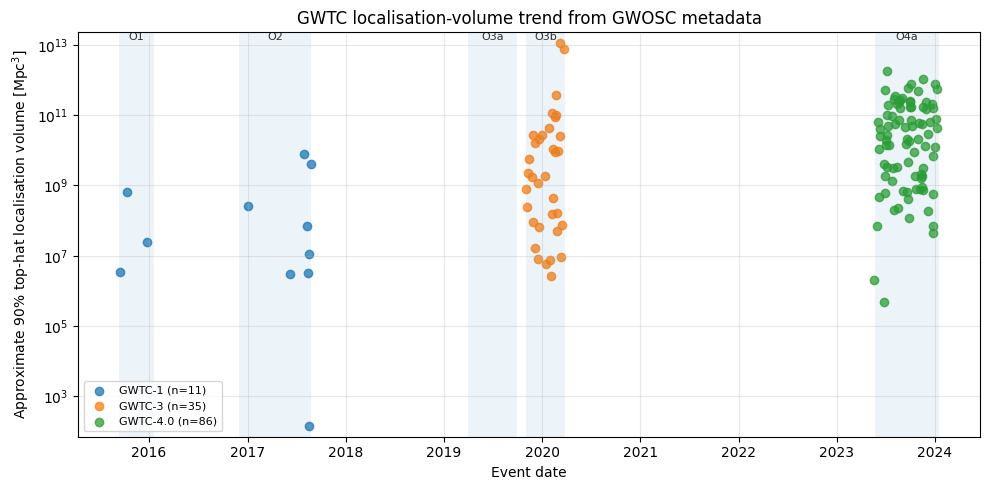

,release_label,n_events,median_volume_mpc3,p16_volume_mpc3,p84_volume_mpc3,median_sky_area_deg2,median_distance_mpc
0,GWTC-1,11,2.438387e+07,3.154038e+06,1.974093e+09,392.000000,990.0
1,GWTC-3,35,1.855013e+09,3.136092e+07,6.973846e+10,1400.000000,1620.0
2,GWTC-4.0,86,2.302013e+10,6.944229e+08,2.375997e+11,2421.152343,2700.0


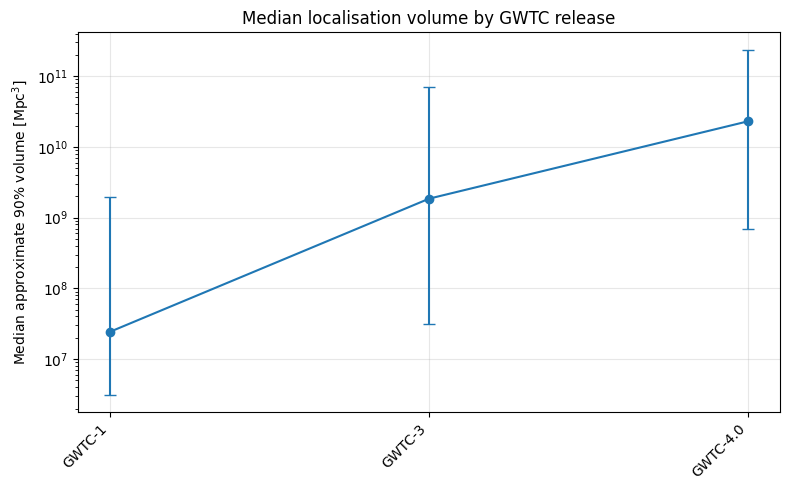


GW190814 not found in usable plotted rows.


In [4]:
# ============================================================
# GWTC 1–4 localisation-volume trend from GWOSC metadata
#
# Catalogues included:
#   - GWTC-1-confident
#   - GWTC-2
#   - GWTC-3-confident
#   - GWTC-4.0
#
# Main quantity:
#   Approximate top-hat localisation volume:
#
#       V ≈ (Omega / 3) * (d_high^3 - d_low^3)
#
# where:
#   Omega = 90% sky area in steradians
#   d_low, d_high = luminosity distance credible interval endpoints
#
# This is a quick-look comparison, not a full 3D skymap volume.
# ============================================================

# If needed in a fresh notebook:
%pip install -q requests pandas numpy matplotlib astropy astropy-healpix

import os
import io
import re
import gzip
import time
import tarfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from astropy.time import Time
from astropy.io import fits

try:
    from astropy_healpix import uniq_to_level_ipix, level_to_nside
    HAS_ASTROPY_HEALPIX = True
except Exception:
    HAS_ASTROPY_HEALPIX = False


# ------------------------------------------------------------
# User controls
# ------------------------------------------------------------

CATALOGS = [
    ("GWTC-1-confident", "GWTC-1"),
    ("GWTC-2", "GWTC-2"),
    ("GWTC-3-confident", "GWTC-3"),
    ("GWTC-4.0", "GWTC-4.0"),
]

# Set to False if you do not want to download the ~268 MB O4 skymap archive.
DOWNLOAD_GWTC4_SKYMAP_ARCHIVE = True

# For O4 skymap fallback
ZENODO_RECORDS_TO_TRY = [
    "17014085",  # newer reweighted PE record, if available
    "16053484",  # original GWTC-4.0 PE/skymap record
]

CREDIBLE_LEVEL = 0.90


# ------------------------------------------------------------
# General helper functions
# ------------------------------------------------------------

def get_json(url, timeout=90):
    """Fetch JSON with a small amount of error handling."""
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


def fetch_all_pages(url, timeout=90):
    """Follow GWOSC API pagination and return combined results."""
    results = []
    next_url = url

    while next_url:
        data = get_json(next_url, timeout=timeout)
        results.extend(data.get("results", []))
        next_url = data.get("next")

    return results


def safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def param_list_to_dict(param_list):
    """
    Convert GWOSC v2 parameter list into:
        {parameter_name: {best, upper_error, lower_error, unit, ...}}
    """
    out = {}
    for p in param_list or []:
        name = p.get("name")
        if name:
            out[name] = p
    return out


def choose_preferred_pe_parameter_set(parameter_sets):
    """
    Choose a preferred parameter-estimation record.
    """
    pe_sets = [
        p for p in parameter_sets
        if p.get("pipeline_type") == "pe"
    ]

    if not pe_sets:
        return None

    preferred = [p for p in pe_sets if p.get("is_preferred") is True]
    if preferred:
        return preferred[0]

    with_distance = []
    for p in pe_sets:
        pdict = param_list_to_dict(p.get("parameters", []))
        if "luminosity_distance" in pdict:
            with_distance.append(p)

    if with_distance:
        return with_distance[0]

    return pe_sets[0]


def parameter_value(pdict, key):
    """
    Return best, lower_error, upper_error for a parameter.
    """
    if key not in pdict:
        return np.nan, np.nan, np.nan

    p = pdict[key]
    best = safe_float(p.get("best"))
    lo = safe_float(p.get("lower_error"))
    hi = safe_float(p.get("upper_error"))

    return best, lo, hi


def distance_bounds_from_params(pdict):
    """
    GWOSC convention:
      best = median
      lower_error is usually negative
      upper_error is positive
    """
    d, lo, hi = parameter_value(pdict, "luminosity_distance")

    if not np.isfinite(d) or not np.isfinite(lo) or not np.isfinite(hi):
        return np.nan, np.nan, np.nan

    d_low = d + lo if lo < 0 else d - lo
    d_high = d + hi if hi > 0 else d - hi

    if d_low <= 0 or d_high <= 0 or d_high <= d_low:
        return d, np.nan, np.nan

    return d, d_low, d_high


def sky_area_from_params(pdict):
    """
    Pull sky_area if exposed in parameter list.
    Usually in deg^2.
    """
    for key in ["sky_area", "area_90", "Area90", "area90"]:
        if key in pdict:
            val, _, _ = parameter_value(pdict, key)
            if np.isfinite(val):
                return val
    return np.nan


def deg2_to_sr(area_deg2):
    return area_deg2 * (np.pi / 180.0) ** 2


def top_hat_volume(area_deg2, d_low, d_high):
    omega = deg2_to_sr(area_deg2)
    return (omega / 3.0) * (d_high**3 - d_low**3)


def gps_to_datetime(gps):
    if not np.isfinite(gps):
        return pd.NaT
    return Time(gps, format="gps").datetime


# ------------------------------------------------------------
# Skymap helper functions for GWTC-4.0 fallback
# ------------------------------------------------------------

def find_gwtc4_skymap_archive_url():
    """
    Find the GWTC-4.0 archived skymaps tarball from Zenodo.
    """
    for rec_id in ZENODO_RECORDS_TO_TRY:
        api_url = f"https://zenodo.org/api/records/{rec_id}"
        try:
            data = get_json(api_url, timeout=90)
        except Exception as e:
            print(f"Could not read Zenodo record {rec_id}: {e}")
            continue

        for f in data.get("files", []):
            key = f.get("key", "")
            if "Archived_Skymaps" in key and key.endswith(".tar.gz"):
                return f["links"]["self"], key, rec_id

    return None, None, None


def download_file(url, local_path, chunk_size=1024 * 1024):
    """
    Download a file if not already present.
    """
    if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
        print(f"Already have: {local_path}")
        return local_path

    print(f"Downloading to {local_path}")
    print("This may take a few minutes.")

    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(local_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

    print(f"Downloaded: {local_path}")
    return local_path


def compute_credible_sky_area_from_prob_and_area(prob, area_sr, credible_level=0.90):
    """
    Highest-posterior-density sky area.
    Works for equal-area and multi-order skymaps.
    """
    prob = np.asarray(prob, dtype=float)
    area_sr = np.asarray(area_sr, dtype=float)

    valid = (
        np.isfinite(prob) &
        np.isfinite(area_sr) &
        (prob >= 0) &
        (area_sr > 0)
    )

    prob = prob[valid]
    area_sr = area_sr[valid]

    if prob.size == 0 or prob.sum() <= 0:
        return np.nan

    prob = prob / prob.sum()
    prob_density = prob / area_sr

    order = np.argsort(prob_density)[::-1]
    cum = np.cumsum(prob[order])

    idx = np.searchsorted(cum, credible_level)
    selected = order[:idx + 1]

    area_credible_sr = area_sr[selected].sum()
    area_credible_deg2 = area_credible_sr * (180.0 / np.pi) ** 2

    return area_credible_deg2


def sky_area90_from_fits_bytes(raw_bytes, filename="skymap.fits", credible_level=0.90):
    """
    Compute 90% credible sky area from a FITS or FITS.GZ skymap.

    Supports:
      - regular HEALPix maps with PROB + NSIDE
      - multi-order maps with UNIQ + PROBDENSITY or PROB
    """
    if filename.endswith(".gz"):
        file_obj = gzip.GzipFile(fileobj=io.BytesIO(raw_bytes))
    else:
        file_obj = io.BytesIO(raw_bytes)

    with fits.open(file_obj, memmap=False) as hdul:
        target_hdu = None

        for hdu in hdul:
            if getattr(hdu, "data", None) is not None and hasattr(hdu.data, "names"):
                names_upper = [n.upper() for n in hdu.data.names]
                if ("PROB" in names_upper) or ("PROBDENSITY" in names_upper):
                    target_hdu = hdu
                    break

        if target_hdu is None:
            return np.nan

        data = target_hdu.data
        header = target_hdu.header
        names = {n.upper(): n for n in data.names}

        # Multi-order skymap
        if "UNIQ" in names:
            if not HAS_ASTROPY_HEALPIX:
                return np.nan

            uniq = np.asarray(data[names["UNIQ"]], dtype=np.int64)
            levels, ipix = uniq_to_level_ipix(uniq)
            nsides = level_to_nside(levels)
            area_sr = 4.0 * np.pi / (12.0 * nsides.astype(float)**2)

            if "PROB" in names:
                prob = np.asarray(data[names["PROB"]], dtype=float)
            elif "PROBDENSITY" in names:
                prob_density = np.asarray(data[names["PROBDENSITY"]], dtype=float)
                prob = prob_density * area_sr
            else:
                return np.nan

            return compute_credible_sky_area_from_prob_and_area(
                prob, area_sr, credible_level=credible_level
            )

        # Regular equal-area HEALPix skymap
        if "PROB" in names and "NSIDE" in header:
            prob = np.asarray(data[names["PROB"]], dtype=float)
            nside = int(header["NSIDE"])
            area_sr = np.full_like(prob, 4.0 * np.pi / (12.0 * nside**2), dtype=float)

            return compute_credible_sky_area_from_prob_and_area(
                prob, area_sr, credible_level=credible_level
            )

    return np.nan


def choose_o4_skymap_member(member_names, event_name):
    """
    Pick a skymap file for a GWTC-4.0 event.

    Preference order:
      - contains event name
      - FITS/FITS.GZ
      - prefer Mixed / reweighted-style names if present
    """
    candidates = [
        m for m in member_names
        if event_name in os.path.basename(m)
        and m.lower().endswith((".fits", ".fits.gz"))
    ]

    if not candidates:
        candidates = [
            m for m in member_names
            if event_name in m
            and m.lower().endswith((".fits", ".fits.gz"))
        ]

    if not candidates:
        return None

    def score(name):
        low = name.lower()
        s = 0
        if "mixed" in low:
            s += 100
        if "rw" in low or "reweight" in low:
            s += 50
        if "xo4a" in low:
            s += 20
        if "combined" in low:
            s += 10
        return s

    candidates = sorted(candidates, key=lambda x: (score(x), -len(x)), reverse=True)
    return candidates[0]


def fill_o4_sky_areas_from_archive(events_df):
    """
    For GWTC-4.0 rows missing sky_area_deg2, compute it from the skymap archive.
    """
    missing_mask = (
        (events_df["catalog_name"] == "GWTC-4.0") &
        (~np.isfinite(events_df["sky_area_deg2"]))
    )

    missing_events = events_df.loc[missing_mask, "event_name"].unique().tolist()

    if len(missing_events) == 0:
        print("No GWTC-4.0 sky areas missing; no skymap archive needed.")
        return events_df

    if not DOWNLOAD_GWTC4_SKYMAP_ARCHIVE:
        print(f"GWTC-4.0 sky areas missing for {len(missing_events)} events.")
        print("DOWNLOAD_GWTC4_SKYMAP_ARCHIVE=False, so leaving them as NaN.")
        return events_df

    archive_url, archive_name, rec_id = find_gwtc4_skymap_archive_url()

    if archive_url is None:
        print("Could not find GWTC-4.0 skymap archive on Zenodo.")
        return events_df

    print(f"Using Zenodo record {rec_id}")
    print(f"Skymap archive: {archive_name}")

    local_archive = archive_name
    download_file(archive_url, local_archive)

    print("Opening skymap archive...")
    with tarfile.open(local_archive, "r:gz") as tar:
        members = [
            m for m in tar.getmembers()
            if m.isfile() and m.name.lower().endswith((".fits", ".fits.gz"))
        ]

        member_names = [m.name for m in members]
        member_lookup = {m.name: m for m in members}

        area_cache = {}

        for i, event_name in enumerate(missing_events, start=1):
            member_name = choose_o4_skymap_member(member_names, event_name)

            if member_name is None:
                area_cache[event_name] = np.nan
                continue

            try:
                raw = tar.extractfile(member_lookup[member_name]).read()
                area = sky_area90_from_fits_bytes(
                    raw,
                    filename=member_name,
                    credible_level=CREDIBLE_LEVEL
                )
                area_cache[event_name] = area

            except Exception as e:
                print(f"Could not compute sky area for {event_name}: {e}")
                area_cache[event_name] = np.nan

            if i % 10 == 0:
                print(f"Processed {i}/{len(missing_events)} O4 skymaps...")

    for event_name, area in area_cache.items():
        idx = (
            (events_df["catalog_name"] == "GWTC-4.0") &
            (events_df["event_name"] == event_name)
        )
        events_df.loc[idx, "sky_area_deg2"] = area

    return events_df


# ------------------------------------------------------------
# 1. Pull event lists + PE parameters from GWOSC v2
# ------------------------------------------------------------

rows = []

for catalog_name, release_label in CATALOGS:
    print(f"\nFetching {catalog_name}")

    events_url = (
        f"https://gwosc.org/api/v2/catalogs/{catalog_name}/events"
        f"?format=json&pagesize=200"
    )

    try:
        events = fetch_all_pages(events_url)
    except Exception as e:
        print(f"  Could not fetch {catalog_name}: {e}")
        continue

    print(f"  Events listed: {len(events)}")

    for n, ev in enumerate(events, start=1):
        event_name = ev.get("name")
        gps = safe_float(ev.get("gps"))
        detail_url = ev.get("detail_url")

        if event_name is None or detail_url is None:
            continue

        try:
            detail = get_json(detail_url.replace("format=api", "format=json"))
            params_url = detail.get("parameters_url")

            if not params_url:
                continue

            param_sets_json = get_json(params_url.replace("format=api", "format=json"))
            param_sets = param_sets_json.get("results", [])

            pe = choose_preferred_pe_parameter_set(param_sets)

            if pe is None:
                continue

            pdict = param_list_to_dict(pe.get("parameters", []))

            d_med, d_low, d_high = distance_bounds_from_params(pdict)
            sky_area_deg2 = sky_area_from_params(pdict)

            # Keep row even if sky_area is missing, so O4 can be filled later
            if not np.isfinite(d_low) or not np.isfinite(d_high):
                continue

            rows.append({
                "event_name": event_name,
                "catalog_name": catalog_name,
                "release_label": release_label,
                "run": detail.get("run"),
                "gps": gps,
                "event_date": gps_to_datetime(gps),
                "detectors": ",".join(detail.get("detectors", [])),
                "pe_name": pe.get("name"),
                "pe_pipeline": pe.get("pipeline"),
                "waveform_family": pe.get("waveform_family"),
                "sky_area_deg2": sky_area_deg2,
                "d_median_mpc": d_med,
                "d_low_mpc": d_low,
                "d_high_mpc": d_high,
            })

        except Exception as e:
            print(f"  Skipping {event_name}: {e}")

        time.sleep(0.03)

events_df = pd.DataFrame(rows)

if len(events_df) == 0:
    raise RuntimeError("No usable PE rows found.")

print("\nInitial extracted rows:")
print(events_df.groupby("release_label").size())


# ------------------------------------------------------------
# 2. Fill missing GWTC-4.0 sky areas from skymap archive if needed
# ------------------------------------------------------------

events_df = fill_o4_sky_areas_from_archive(events_df)


# ------------------------------------------------------------
# 3. Compute approximate top-hat volumes
# ------------------------------------------------------------

events_df["approx_volume_mpc3"] = np.nan
events_df["approx_volume_gpc3"] = np.nan

valid_volume = (
    np.isfinite(events_df["sky_area_deg2"]) &
    np.isfinite(events_df["d_low_mpc"]) &
    np.isfinite(events_df["d_high_mpc"])
)

events_df.loc[valid_volume, "approx_volume_mpc3"] = top_hat_volume(
    events_df.loc[valid_volume, "sky_area_deg2"],
    events_df.loc[valid_volume, "d_low_mpc"],
    events_df.loc[valid_volume, "d_high_mpc"]
)

events_df.loc[valid_volume, "approx_volume_gpc3"] = (
    events_df.loc[valid_volume, "approx_volume_mpc3"] / 1e9
)

usable = events_df[np.isfinite(events_df["approx_volume_mpc3"])].copy()
usable = usable.sort_values("event_date")

print("\nUsable volume rows by release:")
print(usable.groupby("release_label").size())

print("\nRows missing sky_area by release:")
print(
    events_df[~np.isfinite(events_df["sky_area_deg2"])]
    .groupby("release_label")
    .size()
)

display(
    usable[
        [
            "event_name",
            "release_label",
            "run",
            "event_date",
            "sky_area_deg2",
            "d_low_mpc",
            "d_high_mpc",
            "approx_volume_mpc3",
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 4. Plot helpers: observing-run shading
# ------------------------------------------------------------

OBSERVING_RUNS = [
    ("O1",  "2015-09-12", "2016-01-19"),
    ("O2",  "2016-11-30", "2017-08-25"),
    ("O3a", "2019-04-01", "2019-10-01"),
    ("O3b", "2019-11-01", "2020-03-27"),
    ("O4a", "2023-05-24", "2024-01-16"),
]

def shade_observing_runs(ax):
    for label, start, end in OBSERVING_RUNS:
        start_dt = pd.to_datetime(start)
        end_dt = pd.to_datetime(end)

        ax.axvspan(start_dt, end_dt, alpha=0.08)

        # Put the run label near the top of the plot
        y_top = ax.get_ylim()[1]
        ax.text(
            start_dt + (end_dt - start_dt) / 2,
            y_top,
            label,
            ha="center",
            va="top",
            fontsize=8,
            alpha=0.8
        )


# ------------------------------------------------------------
# 5. Plot: localisation volume vs event date
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
ax = plt.gca()

for release_label, group in usable.groupby("release_label"):
    ax.scatter(
        group["event_date"],
        group["approx_volume_mpc3"],
        alpha=0.75,
        label=f"{release_label} (n={len(group)})"
    )

ax.set_yscale("log")
ax.set_xlabel("Event date")
ax.set_ylabel("Approximate 90% top-hat localisation volume [Mpc$^3$]")
ax.set_title("GWTC localisation-volume trend from GWOSC metadata")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# set y limits before adding run labels
finite_y = usable["approx_volume_mpc3"].dropna()
ax.set_ylim(finite_y.min() * 0.5, finite_y.max() * 2.0)
shade_observing_runs(ax)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Plot: median approximate volume by catalogue
# ------------------------------------------------------------

release_order = [label for _, label in CATALOGS]
usable["release_label"] = pd.Categorical(
    usable["release_label"],
    categories=release_order,
    ordered=True
)

release_summary = (
    usable
    .groupby("release_label", observed=True)
    .agg(
        n_events=("event_name", "count"),
        median_volume_mpc3=("approx_volume_mpc3", "median"),
        p16_volume_mpc3=("approx_volume_mpc3", lambda x: x.quantile(0.16)),
        p84_volume_mpc3=("approx_volume_mpc3", lambda x: x.quantile(0.84)),
        median_sky_area_deg2=("sky_area_deg2", "median"),
        median_distance_mpc=("d_median_mpc", "median"),
    )
    .reset_index()
)

display(release_summary)

plt.figure(figsize=(8, 5))
ax = plt.gca()

x = np.arange(len(release_summary))
y = release_summary["median_volume_mpc3"].values
yerr_lower = y - release_summary["p16_volume_mpc3"].values
yerr_upper = release_summary["p84_volume_mpc3"].values - y

ax.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=4
)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(release_summary["release_label"], rotation=45, ha="right")
ax.set_ylabel("Median approximate 90% volume [Mpc$^3$]")
ax.set_title("Median localisation volume by GWTC release")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Highlight GW190814, if present
# ------------------------------------------------------------

gw190814 = usable[usable["event_name"] == "GW190814"]

if len(gw190814) > 0:
    row = gw190814.iloc[0]
    v = row["approx_volume_mpc3"]
    percentile = (usable["approx_volume_mpc3"] <= v).mean() * 100

    print("\nGW190814 quick comparison")
    print("------------------------")
    print(f"Release: {row['release_label']}")
    print(f"Sky area: {row['sky_area_deg2']:.3f} deg^2")
    print(f"Distance interval: {row['d_low_mpc']:.1f}–{row['d_high_mpc']:.1f} Mpc")
    print(f"Approx. volume: {v:,.0f} Mpc^3")
    print(f"Percentile among plotted events: {percentile:.1f}%")
else:
    print("\nGW190814 not found in usable plotted rows.")


Trying catalogues for GWTC-1...
  Using GWTC-1-confident: 11 events listed

Trying catalogues for GWTC-2...
  Using GWTC-2.1-confident: 54 events listed

Trying catalogues for GWTC-3...
  Using GWTC-3-confident: 35 events listed
  Skipping GW200308_173609: 502 Server Error: Proxy Error for url: https://gwosc.org/api/v2/event-versions/GW200308_173609-v1/parameters?format=json

Trying catalogues for GWTC-4.0...
  Using GWTC-4.0: 129 events listed

Raw rows by source plot label:


,source_plot_label,n_raw_rows
0,GWTC-1,11
1,GWTC-2,54
2,GWTC-3,34
3,GWTC-4.0,86



Raw rows by detection-date bucket:


,date_bucket,n_raw_rows
0,GWTC-1,21
1,GWTC-2,44
2,GWTC-3,34
3,GWTC-4.0,85
4,Other,1


Using Zenodo record 17014085
Skymap archive: IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps.tar.gz
Already have: IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps.tar.gz
Opening skymap archive...
Processed 10/86 O4 skymaps...
Processed 20/86 O4 skymaps...
Processed 30/86 O4 skymaps...
Processed 40/86 O4 skymaps...
Processed 50/86 O4 skymaps...
Processed 60/86 O4 skymaps...
Processed 70/86 O4 skymaps...
Processed 80/86 O4 skymaps...

Usable rows by source plot label:


...


Usable rows by detection-date bucket:


,date_bucket,n_usable_rows
0,GWTC-1,21
1,GWTC-2,44
2,GWTC-3,34
3,GWTC-4.0,85
4,Other,1



Final unique plotted events by plot label:


,plot_label,n_events
0,GWTC-1,11
1,GWTC-2,44
2,GWTC-3,34
3,GWTC-4.0,86


,event_name,plot_label,source_catalog,event_date,sky_area_deg2,d_low_mpc,d_high_mpc,approx_volume_mpc3
10,GW150914,GWTC-1,GWTC-1-confident,2015-09-14 09:51:21.400,182.0,270.0,590.0,3.431685e+06
9,GW151012,GWTC-1,GWTC-1-confident,2015-10-12 09:55:19.400,1523.0,590.0,1630.0,6.379639e+08
8,GW151226,GWTC-1,GWTC-1-confident,2015-12-26 03:39:29.600,1033.0,260.0,630.0,2.438387e+07
7,GW170104,GWTC-1,GWTC-1-confident,2017-01-04 10:12:35.600,921.0,560.0,1430.0,2.570415e+08
6,GW170608,GWTC-1,GWTC-1-confident,2017-06-08 02:01:53.500,392.0,210.0,440.0,3.021989e+06
5,GW170729,GWTC-1,GWTC-1-confident,2017-07-29 18:57:06.300,1041.0,1480.0,4240.0,7.714491e+09
4,GW170809,GWTC-1,GWTC-1-confident,2017-08-09 08:28:58.800,308.0,640.0,1350.0,6.874760e+07
3,GW170814,GWTC-1,GWTC-1-confident,2017-08-14 10:31:20.500,87.0,380.0,750.0,3.242070e+06
2,GW170817,GWTC-1,GWTC-1-confident,2017-08-17 12:41:41.400,16.0,25.0,47.0,1.432888e+02
1,GW170818,GWTC-1,GWTC-1-confident,2017-08-18 02:25:46.100,39.0,680.0,1480.0,1.159242e+07


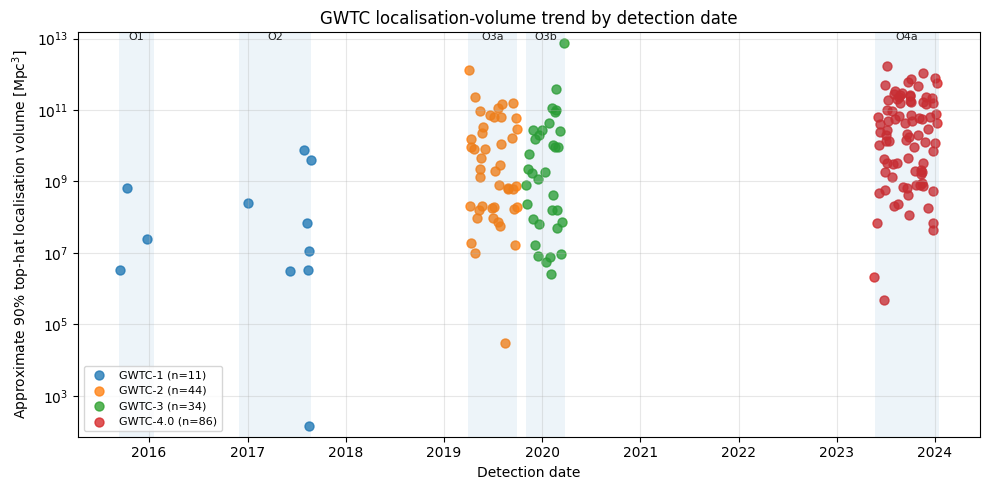

,plot_label,n_events,median_volume_mpc3,p16_volume_mpc3,p84_volume_mpc3,median_sky_area_deg2,median_distance_mpc
0,GWTC-1,11,2.438387e+07,3.154038e+06,1.974093e+09,392.000000,990.0
1,GWTC-2,44,2.105972e+09,9.533248e+07,6.660082e+10,1000.000000,2080.0
2,GWTC-3,34,1.813329e+09,2.611310e+07,3.861217e+10,1250.000000,1550.0
3,GWTC-4.0,86,2.302013e+10,6.944229e+08,2.375997e+11,2421.152343,2700.0


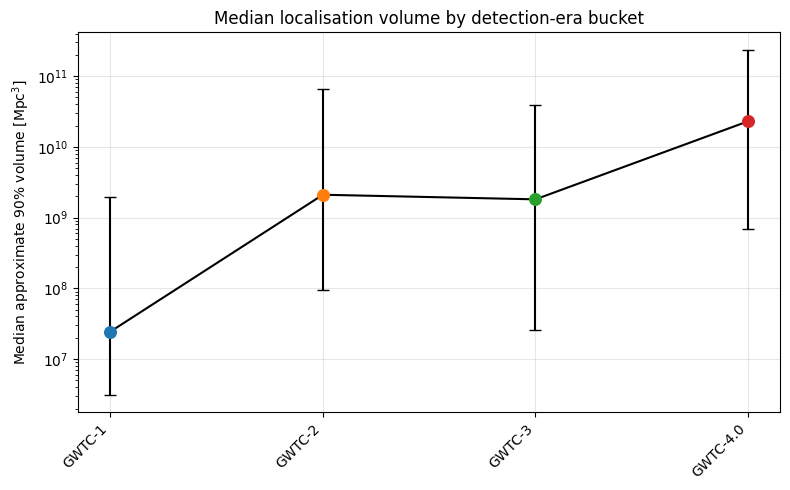


GW190814 quick comparison
------------------------
Plot label: GWTC-2
Source catalogue used: GWTC-2.1-confident
Detection date: 2019-08-14 21:11:16
Sky area: 22.000 deg^2
Distance interval: 180.0–270.0 Mpc
Approx. volume: 30,941 Mpc^3
Percentile among plotted events: 1.1%


In [5]:
# ============================================================
# Corrected GWTC 1–4 localisation-volume trend plot
#
# Fixes:
#   1. Explicitly includes GWTC-2 via GWTC-2.1-confident
#   2. Uses detection date, not catalogue/public-release date
#   3. Assigns events to GWTC/O-run buckets by detection date
#   4. Uses fixed colours so catalogues are not visually confused
#
# Requires helper functions already defined in the previous big cell:
#   fetch_all_pages, get_json, safe_float,
#   choose_preferred_pe_parameter_set, param_list_to_dict,
#   distance_bounds_from_params, sky_area_from_params,
#   top_hat_volume, fill_o4_sky_areas_from_archive
# ============================================================

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from astropy.time import Time

# ------------------------------------------------------------
# 0. Check that previous helper functions exist
# ------------------------------------------------------------

required_helpers = [
    "fetch_all_pages",
    "get_json",
    "safe_float",
    "choose_preferred_pe_parameter_set",
    "param_list_to_dict",
    "distance_bounds_from_params",
    "sky_area_from_params",
    "top_hat_volume",
]

missing_helpers = [h for h in required_helpers if h not in globals()]

if missing_helpers:
    raise RuntimeError(
        "Missing helper functions from the previous big GWTC cell: "
        + ", ".join(missing_helpers)
        + "\nRun the previous helper-function cell first, then run this corrected plotting cell."
    )


# ------------------------------------------------------------
# 1. Catalogue choices
# ------------------------------------------------------------
# GWTC-2.1-confident is used as the practical GWTC-2/O3a source here.

CATALOG_SPECS = [
    {
        "plot_label": "GWTC-1",
        "candidates": ["GWTC-1-confident", "GWTC-1"],
    },
    {
        "plot_label": "GWTC-2",
        "candidates": ["GWTC-2.1-confident", "GWTC-2-confident", "GWTC-2"],
    },
    {
        "plot_label": "GWTC-3",
        "candidates": ["GWTC-3-confident", "GWTC-3"],
    },
    {
        "plot_label": "GWTC-4.0",
        "candidates": ["GWTC-4.0"],
    },
]

PLOT_COLOURS = {
    "GWTC-1": "tab:blue",
    "GWTC-2": "tab:orange",
    "GWTC-3": "tab:green",
    "GWTC-4.0": "tab:red",
}

PLOT_ORDER = ["GWTC-1", "GWTC-2", "GWTC-3", "GWTC-4.0"]


# ------------------------------------------------------------
# 2. Detection-date helpers
# ------------------------------------------------------------

def json_format_url(url):
    """
    Force GWOSC API URL to JSON rather than browsable API format.
    """
    if "format=" in url:
        return re.sub(r"format=[^&]+", "format=json", url)
    if "?" in url:
        return url + "&format=json"
    return url + "?format=json"


def detection_datetime_from_event_name(event_name):
    """
    Parse event names like:
        GW190814
        GW231123_135430

    Returns a pandas Timestamp.
    """
    m = re.match(r"GW(\d{2})(\d{2})(\d{2})(?:_(\d{2})(\d{2})(\d{2}))?", event_name)

    if not m:
        return pd.NaT

    yy, mm, dd, hh, minute, ss = m.groups()

    year = 2000 + int(yy)
    month = int(mm)
    day = int(dd)

    hour = int(hh) if hh is not None else 0
    minute = int(minute) if minute is not None else 0
    second = int(ss) if ss is not None else 0

    try:
        return pd.Timestamp(datetime(year, month, day, hour, minute, second))
    except Exception:
        return pd.NaT


def detection_datetime_from_gps(gps):
    """
    Convert GPS detection time to pandas Timestamp.
    """
    if not np.isfinite(gps):
        return pd.NaT

    try:
        return pd.Timestamp(Time(gps, format="gps").datetime)
    except Exception:
        return pd.NaT


def choose_detection_datetime(event_name, gps):
    """
    Prefer GPS detection time if it agrees with the event name.
    Otherwise fall back to event-name date.

    This prevents accidental plotting by release/publication date.
    """
    name_dt = detection_datetime_from_event_name(event_name)
    gps_dt = detection_datetime_from_gps(gps)

    if pd.notna(name_dt) and pd.notna(gps_dt):
        # If GPS date is within a few days of the event-name date, use GPS.
        if abs((gps_dt - name_dt).total_seconds()) < 5 * 24 * 3600:
            return gps_dt
        else:
            return name_dt

    if pd.notna(gps_dt):
        return gps_dt

    return name_dt


# ------------------------------------------------------------
# 3. Observing-run / catalogue bucket assignment
# ------------------------------------------------------------

OBSERVING_RUNS = [
    ("O1",  "2015-09-12", "2016-01-19"),
    ("O2",  "2016-11-30", "2017-08-25"),
    ("O3a", "2019-04-01", "2019-10-01"),
    ("O3b", "2019-11-01", "2020-03-27"),
    ("O4a", "2023-05-24", "2024-01-16"),
]

def release_bucket_from_detection_date(dt):
    """
    Assign event to the GWTC release bucket implied by its detection date.
    """
    if pd.isna(dt):
        return "Unknown"

    dt = pd.Timestamp(dt)

    if pd.Timestamp("2015-09-12") <= dt <= pd.Timestamp("2016-01-19"):
        return "GWTC-1"

    if pd.Timestamp("2016-11-30") <= dt <= pd.Timestamp("2017-08-25"):
        return "GWTC-1"

    if pd.Timestamp("2019-04-01") <= dt <= pd.Timestamp("2019-10-01"):
        return "GWTC-2"

    if pd.Timestamp("2019-11-01") <= dt <= pd.Timestamp("2020-03-27"):
        return "GWTC-3"

    if pd.Timestamp("2023-05-24") <= dt <= pd.Timestamp("2024-01-16"):
        return "GWTC-4.0"

    return "Other"


def shade_observing_runs(ax):
    """
    Shade observing runs on a time-axis plot.
    """
    y_top = ax.get_ylim()[1]

    for label, start, end in OBSERVING_RUNS:
        start_dt = pd.Timestamp(start)
        end_dt = pd.Timestamp(end)

        ax.axvspan(start_dt, end_dt, alpha=0.08)

        ax.text(
            start_dt + (end_dt - start_dt) / 2,
            y_top,
            label,
            ha="center",
            va="top",
            fontsize=8,
            alpha=0.85
        )


# ------------------------------------------------------------
# 4. Pull catalogue rows
# ------------------------------------------------------------

rows = []

for spec in CATALOG_SPECS:

    plot_label = spec["plot_label"]
    chosen_catalog = None
    events = None

    print(f"\nTrying catalogues for {plot_label}...")

    for candidate in spec["candidates"]:

        events_url = (
            f"https://gwosc.org/api/v2/catalogs/{candidate}/events"
            f"?format=json&pagesize=300"
        )

        try:
            candidate_events = fetch_all_pages(events_url)

            if len(candidate_events) > 0:
                chosen_catalog = candidate
                events = candidate_events
                print(f"  Using {candidate}: {len(events)} events listed")
                break

        except Exception as e:
            print(f"  Could not use {candidate}: {e}")

    if chosen_catalog is None or events is None:
        print(f"  No usable catalogue found for {plot_label}")
        continue

    for ev in events:

        event_name = ev.get("name")
        detail_url = ev.get("detail_url")

        if event_name is None or detail_url is None:
            continue

        try:
            detail = get_json(json_format_url(detail_url))

            gps = safe_float(ev.get("gps"))
            if not np.isfinite(gps):
                gps = safe_float(detail.get("gps"))
            if not np.isfinite(gps):
                gps = safe_float(detail.get("GPS"))

            detection_dt = choose_detection_datetime(event_name, gps)
            date_bucket = release_bucket_from_detection_date(detection_dt)

            params_url = detail.get("parameters_url")
            if not params_url:
                continue

            param_sets_json = get_json(json_format_url(params_url))
            param_sets = param_sets_json.get("results", [])

            pe = choose_preferred_pe_parameter_set(param_sets)

            if pe is None:
                continue

            pdict = param_list_to_dict(pe.get("parameters", []))

            d_med, d_low, d_high = distance_bounds_from_params(pdict)
            sky_area_deg2 = sky_area_from_params(pdict)

            if not np.isfinite(d_low) or not np.isfinite(d_high):
                continue

            rows.append({
                "event_name": event_name,
                "source_catalog": chosen_catalog,
                "source_plot_label": plot_label,
                "date_bucket": date_bucket,
                "gps": gps,
                "event_date": detection_dt,
                "run": detail.get("run"),
                "detectors": ",".join(detail.get("detectors", [])) if isinstance(detail.get("detectors"), list) else detail.get("detectors"),
                "pe_name": pe.get("name"),
                "pe_pipeline": pe.get("pipeline"),
                "sky_area_deg2": sky_area_deg2,
                "d_median_mpc": d_med,
                "d_low_mpc": d_low,
                "d_high_mpc": d_high,
            })

        except Exception as e:
            print(f"  Skipping {event_name}: {e}")

        time.sleep(0.02)


raw_events = pd.DataFrame(rows)

if len(raw_events) == 0:
    raise RuntimeError("No usable event rows were pulled.")

print("\nRaw rows by source plot label:")
display(raw_events.groupby("source_plot_label").size().rename("n_raw_rows").reset_index())

print("\nRaw rows by detection-date bucket:")
display(raw_events.groupby("date_bucket").size().rename("n_raw_rows").reset_index())


# ------------------------------------------------------------
# 5. Fill missing O4 sky areas using the skymap archive, if needed
# ------------------------------------------------------------

# The old helper looks for catalog_name == "GWTC-4.0",
# so provide that temporary column.
raw_events["catalog_name"] = raw_events["source_catalog"]

if "fill_o4_sky_areas_from_archive" in globals():
    raw_events = fill_o4_sky_areas_from_archive(raw_events)
else:
    print(
        "fill_o4_sky_areas_from_archive is not defined. "
        "O4 rows without sky_area will remain unusable."
    )


# ------------------------------------------------------------
# 6. Compute volumes
# ------------------------------------------------------------

raw_events["approx_volume_mpc3"] = np.nan
raw_events["approx_volume_gpc3"] = np.nan

valid_volume = (
    np.isfinite(raw_events["sky_area_deg2"]) &
    np.isfinite(raw_events["d_low_mpc"]) &
    np.isfinite(raw_events["d_high_mpc"])
)

raw_events.loc[valid_volume, "approx_volume_mpc3"] = top_hat_volume(
    raw_events.loc[valid_volume, "sky_area_deg2"],
    raw_events.loc[valid_volume, "d_low_mpc"],
    raw_events.loc[valid_volume, "d_high_mpc"]
)

raw_events.loc[valid_volume, "approx_volume_gpc3"] = (
    raw_events.loc[valid_volume, "approx_volume_mpc3"] / 1e9
)

usable_raw = raw_events[np.isfinite(raw_events["approx_volume_mpc3"])].copy()

print("\nUsable rows by source plot label:")
display(usable_raw.groupby("source_plot_label").size().rename("n_usable_rows").reset_index())

print("\nUsable rows by detection-date bucket:")
display(usable_raw.groupby("date_bucket").size().rename("n_usable_rows").reset_index())


# ------------------------------------------------------------
# 7. De-duplicate events sensibly
# ------------------------------------------------------------
# Some catalogues are cumulative/reprocessed, so the same event can appear
# in multiple catalogues. For the time-trend plot, each event should appear once.
#
# Preference rule:
#   keep the row where source_plot_label matches the detection-date bucket.
#   Example:
#       O3a event -> GWTC-2
#       O3b event -> GWTC-3
#       O4a event -> GWTC-4.0

usable_raw["bucket_match"] = (
    usable_raw["source_plot_label"] == usable_raw["date_bucket"]
)

usable_raw["plot_order_rank"] = usable_raw["source_plot_label"].map({
    "GWTC-1": 1,
    "GWTC-2": 2,
    "GWTC-3": 3,
    "GWTC-4.0": 4,
}).fillna(99)

# Sort so that matching bucket rows are preferred.
usable = (
    usable_raw
    .sort_values(
        ["event_name", "bucket_match", "plot_order_rank"],
        ascending=[True, False, True]
    )
    .drop_duplicates(subset=["event_name"], keep="first")
    .copy()
)

# Plot label is the detection-date bucket where recognized.
usable["plot_label"] = usable["date_bucket"]
usable.loc[~usable["plot_label"].isin(PLOT_ORDER), "plot_label"] = usable.loc[
    ~usable["plot_label"].isin(PLOT_ORDER), "source_plot_label"
]

usable = usable.sort_values("event_date")

print("\nFinal unique plotted events by plot label:")
display(usable.groupby("plot_label").size().rename("n_events").reset_index())

display(
    usable[
        [
            "event_name",
            "plot_label",
            "source_catalog",
            "event_date",
            "sky_area_deg2",
            "d_low_mpc",
            "d_high_mpc",
            "approx_volume_mpc3",
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 8. Main plot: localisation volume vs detection date
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
ax = plt.gca()

finite_y = usable["approx_volume_mpc3"].dropna()
ax.set_ylim(finite_y.min() * 0.5, finite_y.max() * 2.0)

for label in PLOT_ORDER:
    group = usable[usable["plot_label"] == label]

    if len(group) == 0:
        continue

    ax.scatter(
        group["event_date"],
        group["approx_volume_mpc3"],
        alpha=0.78,
        s=42,
        color=PLOT_COLOURS[label],
        label=f"{label} (n={len(group)})"
    )

ax.set_yscale("log")
ax.set_xlabel("Detection date")
ax.set_ylabel("Approximate 90% top-hat localisation volume [Mpc$^3$]")
ax.set_title("GWTC localisation-volume trend by detection date")
ax.grid(alpha=0.3)
shade_observing_runs(ax)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Release/bucket summary plot
# ------------------------------------------------------------

usable["plot_label"] = pd.Categorical(
    usable["plot_label"],
    categories=PLOT_ORDER,
    ordered=True
)

release_summary = (
    usable
    .dropna(subset=["plot_label"])
    .groupby("plot_label", observed=True)
    .agg(
        n_events=("event_name", "count"),
        median_volume_mpc3=("approx_volume_mpc3", "median"),
        p16_volume_mpc3=("approx_volume_mpc3", lambda x: x.quantile(0.16)),
        p84_volume_mpc3=("approx_volume_mpc3", lambda x: x.quantile(0.84)),
        median_sky_area_deg2=("sky_area_deg2", "median"),
        median_distance_mpc=("d_median_mpc", "median"),
    )
    .reset_index()
)

display(release_summary)

plt.figure(figsize=(8, 5))
ax = plt.gca()

x = np.arange(len(release_summary))
y = release_summary["median_volume_mpc3"].values
yerr_lower = y - release_summary["p16_volume_mpc3"].values
yerr_upper = release_summary["p84_volume_mpc3"].values - y

ax.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=4,
    color="black"
)

for i, label in enumerate(release_summary["plot_label"]):
    ax.scatter(
        i,
        release_summary.loc[i, "median_volume_mpc3"],
        color=PLOT_COLOURS.get(str(label), "black"),
        s=70,
        zorder=3
    )

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(release_summary["plot_label"], rotation=45, ha="right")
ax.set_ylabel("Median approximate 90% volume [Mpc$^3$]")
ax.set_title("Median localisation volume by detection-era bucket")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. GW190814 quick check
# ------------------------------------------------------------

gw190814 = usable[usable["event_name"] == "GW190814"]

if len(gw190814) > 0:
    row = gw190814.iloc[0]
    v = row["approx_volume_mpc3"]
    percentile = (usable["approx_volume_mpc3"] <= v).mean() * 100

    print("\nGW190814 quick comparison")
    print("------------------------")
    print(f"Plot label: {row['plot_label']}")
    print(f"Source catalogue used: {row['source_catalog']}")
    print(f"Detection date: {row['event_date']}")
    print(f"Sky area: {row['sky_area_deg2']:.3f} deg^2")
    print(f"Distance interval: {row['d_low_mpc']:.1f}–{row['d_high_mpc']:.1f} Mpc")
    print(f"Approx. volume: {v:,.0f} Mpc^3")
    print(f"Percentile among plotted events: {percentile:.1f}%")
else:
    print("\nGW190814 not found in usable plotted rows.")

In [6]:
date_check = usable.copy()

date_check["date_from_event_name"] = date_check["event_name"].apply(
    detection_datetime_from_event_name
)

date_check["date_difference_days"] = (
    date_check["event_date"] - date_check["date_from_event_name"]
).dt.total_seconds() / 86400

display(
    date_check[
        [
            "event_name",
            "plot_label",
            "source_catalog",
            "event_date",
            "date_from_event_name",
            "date_difference_days",
        ]
    ]
    .sort_values("event_date")
    .head(30)
)

print("\nMaximum absolute date mismatch in days:")
print(date_check["date_difference_days"].abs().max())

print("\nDetection-date ranges by label:")
display(
    date_check
    .groupby("plot_label")
    .agg(
        n=("event_name", "count"),
        first_detection=("event_date", "min"),
        last_detection=("event_date", "max"),
    )
)

,event_name,plot_label,source_catalog,event_date,date_from_event_name,date_difference_days
10,GW150914,GWTC-1,GWTC-1-confident,2015-09-14 09:51:21.400,2015-09-14 00:00:00,0.410664
9,GW151012,GWTC-1,GWTC-1-confident,2015-10-12 09:55:19.400,2015-10-12 00:00:00,0.413419
8,GW151226,GWTC-1,GWTC-1-confident,2015-12-26 03:39:29.600,2015-12-26 00:00:00,0.152426
7,GW170104,GWTC-1,GWTC-1-confident,2017-01-04 10:12:35.600,2017-01-04 00:00:00,0.425412
6,GW170608,GWTC-1,GWTC-1-confident,2017-06-08 02:01:53.500,2017-06-08 00:00:00,0.084647
5,GW170729,GWTC-1,GWTC-1-confident,2017-07-29 18:57:06.300,2017-07-29 00:00:00,0.789656
4,GW170809,GWTC-1,GWTC-1-confident,2017-08-09 08:28:58.800,2017-08-09 00:00:00,0.353458
3,GW170814,GWTC-1,GWTC-1-confident,2017-08-14 10:31:20.500,2017-08-14 00:00:00,0.438432
2,GW170817,GWTC-1,GWTC-1-confident,2017-08-17 12:41:41.400,2017-08-17 00:00:00,0.528951
1,GW170818,GWTC-1,GWTC-1-confident,2017-08-18 02:25:46.100,2017-08-18 00:00:00,0.101228



Maximum absolute date mismatch in days:
0.882824074074074

Detection-date ranges by label:


/tmp/ipykernel_6375/2476712565.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("plot_label")


,n,first_detection,last_detection
plot_label,,,
GWTC-1,11,2015-09-14 09:51:21.400,2017-08-23 13:14:35.500
GWTC-2,44,2019-04-03 05:15:56.200,2019-09-30 13:36:18.200
GWTC-3,34,2019-11-03 01:26:26.500,2020-03-22 09:12:10.300
GWTC-4.0,86,2023-05-18 12:59:45.200,2024-01-09 05:05:08.800


In [7]:
diagnostic = usable.copy()

diagnostic["distance_width_mpc"] = (
    diagnostic["d_high_mpc"] - diagnostic["d_low_mpc"]
)

diagnostic["fractional_distance_width"] = (
    diagnostic["distance_width_mpc"] / diagnostic["d_median_mpc"]
)

summary_diagnostic = (
    diagnostic
    .groupby("plot_label", observed=True)
    .agg(
        n=("event_name", "count"),
        median_sky_area_deg2=("sky_area_deg2", "median"),
        median_distance_mpc=("d_median_mpc", "median"),
        median_distance_width_mpc=("distance_width_mpc", "median"),
        median_fractional_distance_width=("fractional_distance_width", "median"),
        median_volume_mpc3=("approx_volume_mpc3", "median"),
    )
    .reset_index()
)

display(summary_diagnostic)

,plot_label,n,median_sky_area_deg2,median_distance_mpc,median_distance_width_mpc,median_fractional_distance_width,median_volume_mpc3
0,GWTC-1,11,392.000000,990.0,710.0,0.754717,2.438387e+07
1,GWTC-2,44,1000.000000,2080.0,1760.0,1.009988,2.105972e+09
2,GWTC-3,34,1250.000000,1550.0,1735.0,0.921906,1.813329e+09
3,GWTC-4.0,86,2421.152343,2700.0,3300.0,1.101724,2.302013e+10


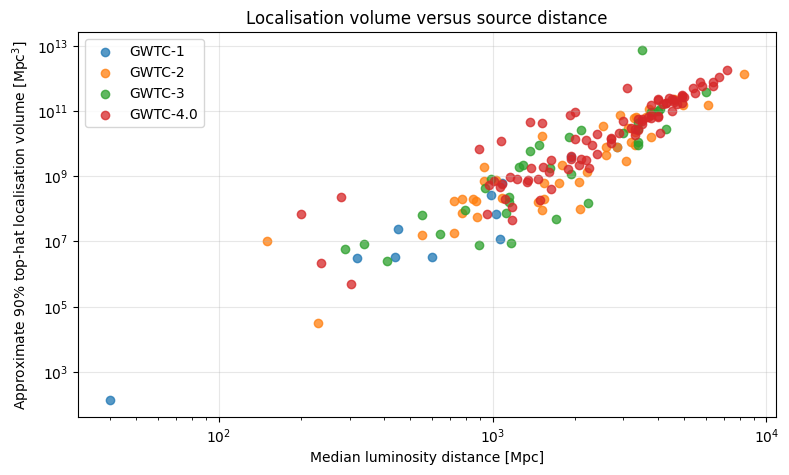

In [8]:
plt.figure(figsize=(9, 5))

for label in PLOT_ORDER:
    group = usable[usable["plot_label"] == label]
    if len(group) == 0:
        continue

    plt.scatter(
        group["d_median_mpc"],
        group["approx_volume_mpc3"],
        alpha=0.75,
        label=label,
        color=PLOT_COLOURS[label],
    )

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Median luminosity distance [Mpc]")
plt.ylabel("Approximate 90% top-hat localisation volume [Mpc$^3$]")
plt.title("Localisation volume versus source distance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()